# Zomato Delivery Operations - EDA
## Focus: Demand Forecasting & Delivery Time Prediction

**Project Goal:**
- Part 1: Forecast order
- Part 2: Predict Delivery Time

**Dataset:** Zomato Delivery Operations (Kaggle)

## 0. Setup & Data Loading

In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
from geopy.distance import geodesic

warnings.filterwarnings('ignore')

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [3]:
# File paths
data_path = '../data/raw/Zomato Dataset.csv'

# Read the CSV file into a DataFrame
df = pd.read_csv(data_path)

print("Data loaded successfully!")
print(f"Orders: {df.shape}")

Data loaded successfully!
Orders: (45584, 20)


## 1. Data Overview & Structure

In [4]:
print("=" * 100)
print("DATASET")
print("=" * 100)
print(df.head(5))
print("=" * 100)
print(df.info())
print("=" * 100)
print(df.describe())

DATASET
       ID Delivery_person_ID  Delivery_person_Age  Delivery_person_Ratings  \
0  0xcdcd      DEHRES17DEL01                 36.0                      4.2   
1  0xd987      KOCRES16DEL01                 21.0                      4.7   
2  0x2784     PUNERES13DEL03                 23.0                      4.7   
3  0xc8b6     LUDHRES15DEL02                 34.0                      4.3   
4  0xdb64      KNPRES14DEL02                 24.0                      4.7   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            30.327968             78.046106                   30.397968   
1            10.003064             76.307589                   10.043064   
2            18.562450             73.916619                   18.652450   
3            30.899584             75.809346                   30.919584   
4            26.463504             80.372929                   26.593504   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_

## 2. Data Quality Assessment

**Critical for both forecasting and prediction:**
- Missing values can break time series models
- Understanding data gaps helps define delivery time prediction

### 2.1 Column Renaming

In [5]:
# Rename columns for ease of use
df = df.rename(columns={
    "ID": "order_id",
    "Delivery_person_ID": "delivery_person_id",
    "Delivery_person_Age": "delivery_person_age",
    "Delivery_person_Ratings": "delivery_person_rating",
    "Restaurant_latitude": "restaurant_lat",
    "Restaurant_longitude": "restaurant_long",
    "Delivery_location_latitude": "delivery_lat",
    "Delivery_location_longitude": "delivery_long",
    "Order_Date": "order_date",
    "Time_Orderd": "order_time",
    "Time_Order_picked": "pickup_time",
    "Weather_conditions": "weather",
    "Road_traffic_density": "traffic_density",
    "Vehicle_condition": "vehicle_condition",
    "Type_of_order": "order_type",
    "Type_of_vehicle": "vehicle_type",
    "multiple_deliveries": "multiple_deliveries",
    "Festival": "festival",
    "City": "city",
    "Time_taken (min)": "time_taken_min"
})

### 2.2 Missing Values & Duplicates

                        Missing Count  Missing Percent
delivery_person_rating           1908         4.185679
delivery_person_age              1854         4.067217
order_time                       1731         3.797385
city                             1200         2.632503
multiple_deliveries               993         2.178396
weather                           616         1.351351
traffic_density                   601         1.318445
festival                          228         0.500176
order_id                            0         0.000000
delivery_person_id                  0         0.000000
restaurant_lat                      0         0.000000
restaurant_long                     0         0.000000
pickup_time                         0         0.000000
order_date                          0         0.000000
delivery_lat                        0         0.000000
delivery_long                       0         0.000000
vehicle_type                        0         0.000000
order_type

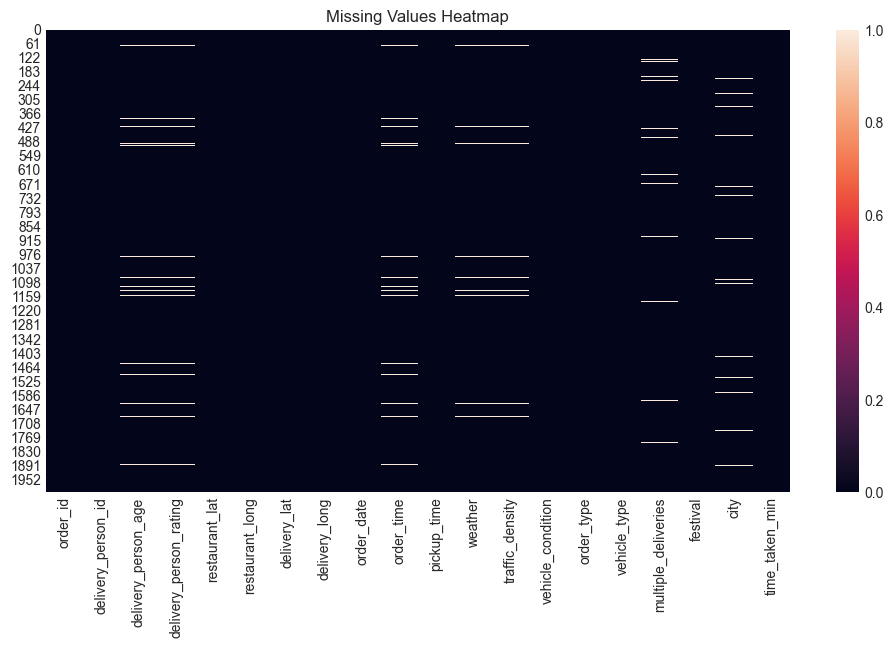

In [6]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing Percent': missing_percent}).sort_values(by='Missing Count',ascending=False)

print(missing_df)

plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull().head(2000))
plt.title("Missing Values Heatmap")
plt.show()

In [7]:
duplicates = df.duplicated().sum()
print(f"Dataset duplicated values are: {duplicates}")

Dataset duplicated values are: 0


## 3. Time Processing & Timestamp Creation

In [8]:
time_columns = ['order_date', 'order_time', 'pickup_time', 'time_taken_min']
for col in time_columns:
    print(df[col].unique())
    print("="*100)

['12-02-2022' '13-02-2022' '04-03-2022' '14-02-2022' '02-04-2022'
 '01-03-2022' '16-03-2022' '20-03-2022' '15-02-2022' '10-03-2022'
 '11-03-2022' '27-03-2022' '26-03-2022' '05-04-2022' '12-03-2022'
 '01-04-2022' '05-03-2022' '11-02-2022' '08-03-2022' '03-04-2022'
 '30-03-2022' '28-03-2022' '18-03-2022' '14-03-2022' '06-04-2022'
 '04-04-2022' '24-03-2022' '19-03-2022' '09-03-2022' '25-03-2022'
 '02-03-2022' '13-03-2022' '29-03-2022' '31-03-2022' '17-03-2022'
 '07-03-2022' '15-03-2022' '16-02-2022' '03-03-2022' '18-02-2022'
 '23-03-2022' '17-02-2022' '06-03-2022' '21-03-2022']
['21:55' '14:55' '17:30' '09:20' '19:50' '20:25' '20:30' '20:40' '21:15'
 '20:20' '22:30' '08:15' '19:30' '12:25' '18:35' '20:35' '23:20' '21:20'
 '23:35' '22:35' '23:25' '13:35' '21:35' '18:55' '14:15' '0.458333333'
 '09:45' '08:40' '0.958333333' '17:25' nan '19:45' '19:10' '10:55' '21:40'
 '0.791666667' '16:45' '11:30' '15:10' '22:45' '22:10' '20:45' '22:50'
 '17:55' '09:25' '20:15' '22:25' '22:40' '23:50' '15:25

In [9]:
def float_to_hhmm(x):
    if pd.isna(x):
        return np.nan
    
    x = str(x)

    if ':' in x:
        return x[:5]
    
    try:
        val = float(x)
    except ValueError:
        return np.nan
    
    total_minutes = val * 24 * 60
    h = int(total_minutes // 60)
    m = int(total_minutes % 60)
    
    return f"{h:02d}:{m:02d}"

def hhmm_to_mins(x):
    if pd.isna(x):
        return np.nan
    
    return int(x[:2]) * 60 + int(x[3:5])

def mins_to_hhmm(x):
    if pd.isna(x):
        return np.nan
    
    x = float(x)
    
    h = int(x // 60)
    m = int(x % 60)
    
    return f"{h:02d}:{m:02d}"
    
# WARNING: This uses target leakage – only acceptable for EDA reconstruction
df['order_time'] = df['order_time'].apply(float_to_hhmm)
df['pickup_time'] = df['pickup_time'].apply(float_to_hhmm)

df['order_time_mins'] = df['order_time'].apply(hhmm_to_mins)
df['pickup_time_mins'] = df['pickup_time'].apply(hhmm_to_mins)

mask = df['order_time_mins'].isna()
df.loc[mask, 'order_time_mins'] = df.loc[mask, 'pickup_time_mins']  - df.loc[mask, 'time_taken_min']

df.loc[mask, 'order_time'] = df.loc[mask, 'order_time_mins'].apply(mins_to_hhmm)

In [10]:
mask_24 = df['order_time'] == '24:00'
df['order_time_fixed'] = df['order_time'].replace('24:00', '00:00')

df['order_timestamp'] = pd.to_datetime(df['order_date'] + ' ' + df['order_time_fixed'], dayfirst=True, errors='coerce')
df.loc[mask_24, 'order_timestamp'] += pd.Timedelta(days=1)

df['order_timestamp'] 

0       2022-02-12 21:55:00
1       2022-02-13 14:55:00
2       2022-03-04 17:30:00
3       2022-02-13 09:20:00
4       2022-02-14 19:50:00
                ...        
45579   2022-03-24 11:35:00
45580   2022-02-16 19:55:00
45581   2022-03-11 23:50:00
45582   2022-03-07 13:35:00
45583   2022-03-02 17:10:00
Name: order_timestamp, Length: 45584, dtype: datetime64[ns]

## 4. Feature Creation

In [11]:
df["distance_km"] = df.apply(
    lambda row: geodesic(
        (row["restaurant_lat"], row["restaurant_long"]),
        (row["delivery_lat"], row["delivery_long"])
    ).km,
    axis=1
)
df['order_hour'] = df['order_timestamp'].dt.hour
df['order_day_of_week'] = df['order_timestamp'].dt.dayofweek

## 5. Time Range & Sorting

In [12]:
df_sorted = df.sort_values('order_timestamp', ascending=True)
start = df_sorted['order_timestamp'].iloc[0]
end = df_sorted['order_timestamp'].iloc[-1]
print(f"Start Date:{start} - End Date:{end}")
print(f"Time Range: {end - start}")

Start Date:2022-02-11 08:10:00 - End Date:2022-04-07 00:00:00
Time Range: 54 days 15:50:00


## 6. Demand Aggregation

In [13]:
df_sorted['order_timestamp_day'] = df_sorted['order_timestamp'].dt.floor('D')
df_sorted['order_timestamp_hour'] = df_sorted['order_timestamp'].dt.floor('H')

df_demand_day = df_sorted.groupby('order_timestamp_day').size().reset_index(name='demand')
df_demand_hour = df_sorted.groupby('order_timestamp_hour').size().reset_index(name='demand')

df_demand_day = df_demand_day.rename(columns={'order_timestamp_day': 'timestamp'})
df_demand_hour = df_demand_hour.rename(columns={'order_timestamp_hour': 'timestamp'})

full_range_day = pd.date_range(start=df_demand_day['timestamp'].min(), end=df_demand_day['timestamp'].max(), freq='D')
full_range_hour = pd.date_range(start=df_demand_hour["timestamp"].min(), end=df_demand_hour["timestamp"].max(), freq="H")


df_demand_day = df_demand_day.set_index('timestamp').reindex(full_range_day).fillna(0).rename_axis('timestamp').reset_index()
df_demand_hour = df_demand_hour.set_index("timestamp").reindex(full_range_hour).fillna(0).rename_axis("timestamp").reset_index()



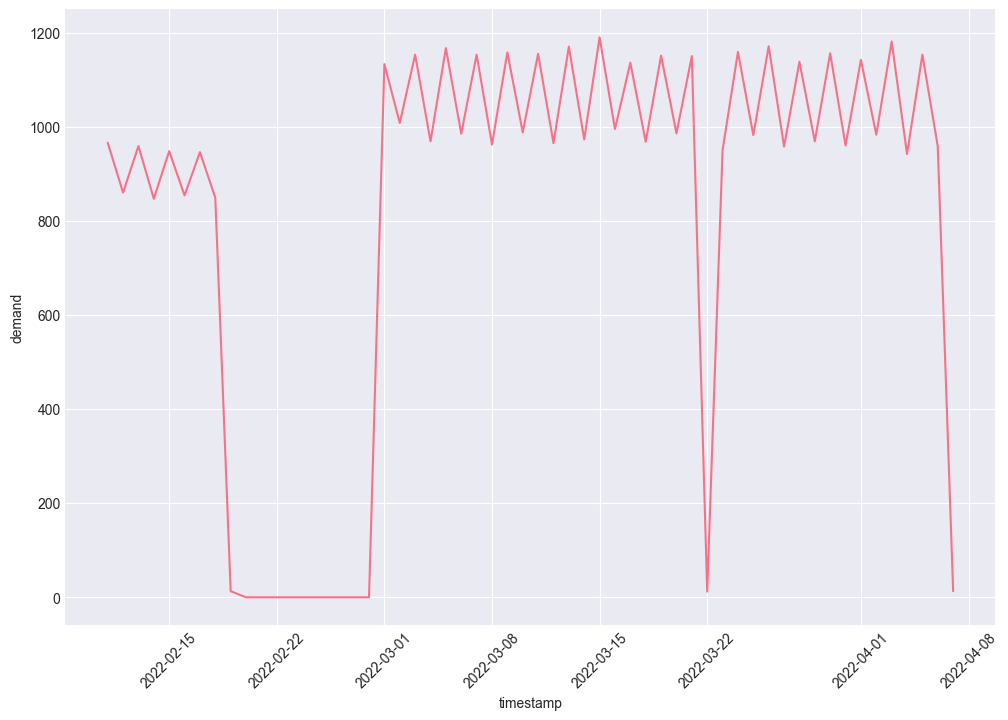

In [14]:
plt.figure(figsize=(12,8))
sns.lineplot(data=df_demand_day, x='timestamp', y='demand')
plt.xticks(rotation=45)
plt.show()

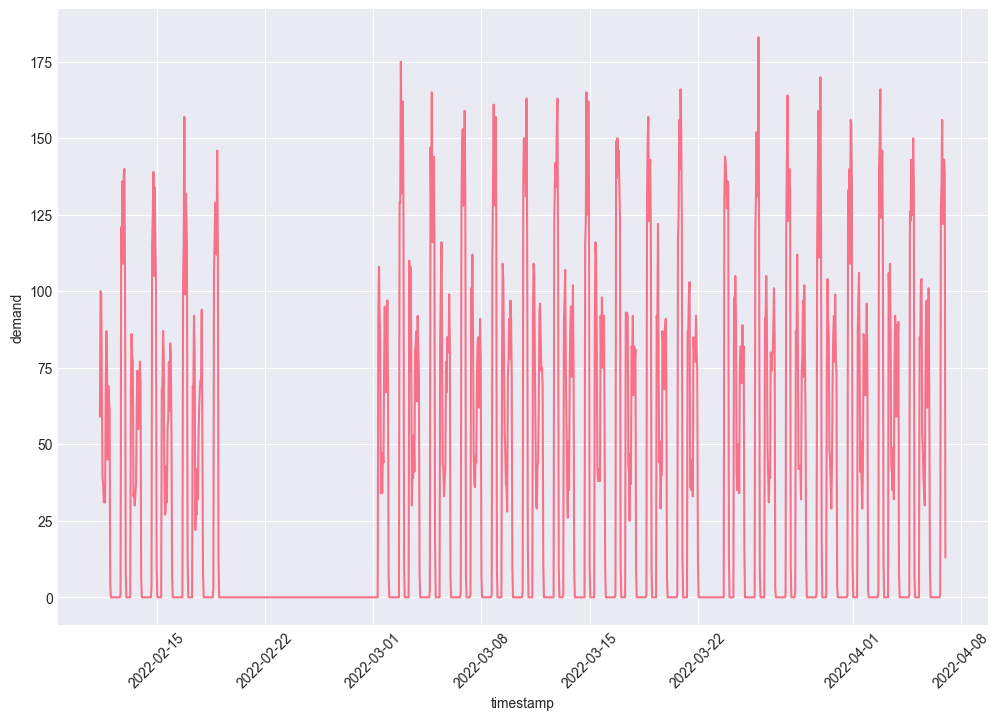

In [15]:
plt.figure(figsize=(12,8))
sns.lineplot(data=df_demand_hour, x='timestamp', y='demand')
plt.xticks(rotation=45)
plt.show()

### Insight:
From the graph we can see a gap in the demand, due to missing data,which can affect the algorithm.

## 7. Getting and cleaning viable dates

In [16]:
df_demand_day['is_missing'] = df_demand_day['demand'] <= 20
streak = 0
missing_streak = []

# Get missing streak days
for val in df_demand_day['is_missing']:
    if val:
        streak += 1
    else:
        streak = 0
    missing_streak.append(streak)

df_demand_day['missing_streak'] = missing_streak

# Define the gaps with more than one day
df_demand_day['is_break'] = df_demand_day["missing_streak"] > 1

# Divide data into blocks
df_demand_day['block'] = (df_demand_day['is_break'] != df_demand_day['is_break'].shift()).cumsum()

df_block_len = df_demand_day.groupby('block')['timestamp'].count().reset_index(name='days')

mask = df_demand_day['block']  == df_block_len.loc[df_block_len['days'].idxmax(), 'block']
df_demand_day_filtered = df_demand_day[mask]
df_demand_day_filtered = df_demand_day_filtered.reset_index().drop(columns = ['index', 'missing_streak', 'is_break', 'block'])

df_demand_day_filtered.loc[df_demand_day_filtered['is_missing'], 'demand'] = np.nan
df_demand_day_filtered["demand"] = df_demand_day_filtered["demand"].interpolate()
df_demand_day_filtered

,timestamp,demand,is_missing
0,2022-03-01,1133.0,False
1,2022-03-02,1008.0,False
2,2022-03-03,1153.0,False
3,2022-03-04,969.0,False
4,2022-03-05,1167.0,False
5,2022-03-06,985.0,False
6,2022-03-07,1153.0,False
7,2022-03-08,962.0,False
8,2022-03-09,1158.0,False
9,2022-03-10,988.0,False


In [ ]:
min_date = df_demand_day_filtered['timestamp'].min()
max_date = df_demand_day_filtered['timestamp'].max()
miss_date = df_demand_day_filtered.loc[df_demand_day_filtered['is_missing'], 'timestamp']

mask = df_demand_hour['timestamp'].between(min_date, max_date)
df_demand_hour_filtered = df_demand_hour[mask]

df_demand_hour_filtered['date'] = df_demand_hour['timestamp'].dt.date
mask = df_demand_hour_filtered['date'].isin(miss_date.dt.date)
df_demand_hour_filtered.loc[mask, 'demand'] = pd.NA

df_demand_hour_filtered['demand'] = (df_demand_hour_filtered['demand'].fillna(df_demand_hour_filtered['demand'].shift(168)))

df_demand_day_filtered =df_demand_day_filtered.drop(columns = ['is_missing'])
df_demand_hour_filtered =df_demand_hour_filtered.drop(columns = ['is_missing'])


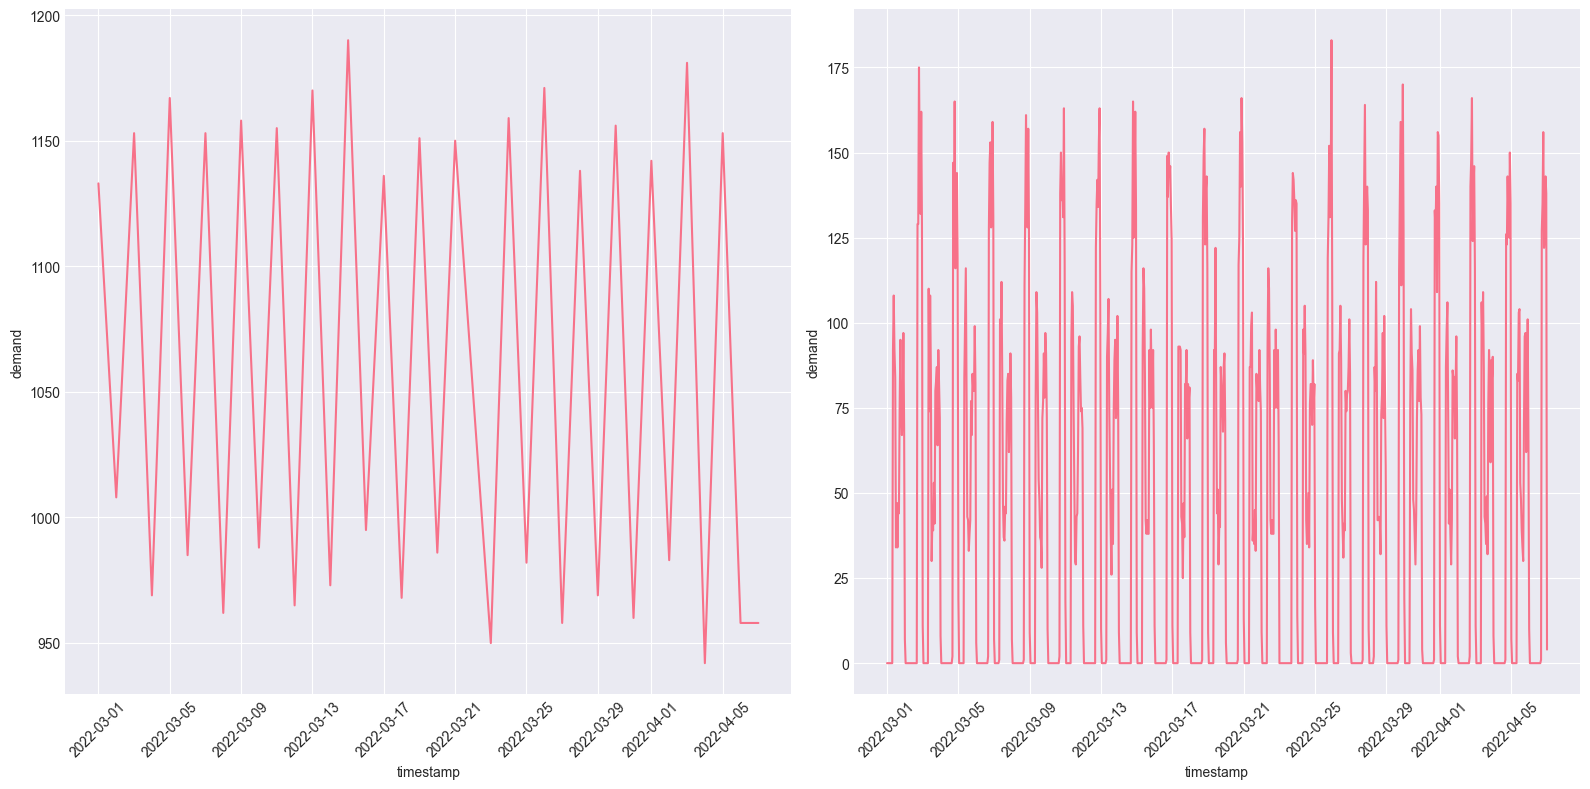

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16,8))

sns.lineplot(data=df_demand_day_filtered, x='timestamp', y='demand', ax=axes[0])
axes[0].tick_params(axis='x', rotation=45)


sns.lineplot(data=df_demand_hour_filtered, x='timestamp', y='demand', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
df_demand_day_filtered.to_csv("../data/processed/daily_clean.csv", index=False)
df_demand_hour_filtered.to_csv("../data/processed/hourly_clean.csv", index=False)

KeyError: "['is_missing'] not found in axis"

## 8. Task Specific Exploration